In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from src.data_process.k_means_clasification import subcluster_macrozona_cluster
import math


In [2]:
def plot_all_clusters(df_data, df_centroids, macrozona, col_medida, titulo_principal):
    clusters = sorted(df_centroids[df_centroids["macrozona"] == macrozona]["id_cluster"].unique())
    n_clusters = len(clusters)
    
    if n_clusters == 0:
        print(f"No se encontraron clusteres para {macrozona}.")
        return

    if n_clusters <= 3:
        n_cols, n_rows = n_clusters, 1
    elif n_clusters == 4:
        n_cols, n_rows = 2, 2  
    elif n_clusters in [5, 6]:
        n_cols, n_rows = 3, 2
    elif n_clusters in [7, 8]:
        n_cols, n_rows = 4, 2
    else:
        n_cols = 3 if n_clusters <= 9 else 4
        n_rows = math.ceil(n_clusters / n_cols)

    fig_width = max(12, 5 * n_cols)
    fig_height = 4.5 * n_rows
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(fig_width, fig_height), sharex=True, sharey=True)
    fig.suptitle(f"{titulo_principal}\nMacrozona: {macrozona}", fontsize=16, fontweight='bold', y=1.05 if n_rows == 1 else 1.02)
    
    axes = np.array(axes).flatten() if n_clusters > 1 else [axes]
    horas = np.arange(1, 25)

    for i, cluster in enumerate(clusters):
        ax = axes[i]
        
        miembros = df_data[(df_data["macrozona"] == macrozona) & (df_data["id_cluster"] == cluster)]
        centro = df_centroids[(df_centroids["macrozona"] == macrozona) & (df_centroids["id_cluster"] == cluster)]
        
        # El centro ahora trae la clave_unica asignada durante la clusterizacion
        clave_medoid = centro["clave_medoid"].iloc[0]
        
        # Conteo usando clave_unica
        n_miembros = miembros["clave_unica"].nunique()

        curvas_miembros = []
        horas = np.arange(1, 25)

        # Iteracion y filtrado usando clave_unica
        for cliente in miembros["clave_unica"].unique():
            curva = miembros[miembros["clave_unica"] == cliente].sort_values("Hora")[col_medida].to_numpy()
            curvas_miembros.append(curva)
            ax.plot(horas, curva, color='gray', alpha=0.25, linewidth=0.8, zorder=1)
        
        curvas_miembros = np.array(curvas_miembros)

        if n_miembros > 2:
            p10 = np.percentile(curvas_miembros, 10, axis=0)
            p90 = np.percentile(curvas_miembros, 90, axis=0)

            ax.fill_between(horas, p10, p90, color='blue', alpha=0.08, zorder=2, label='Nucleo central 80%')

        # Filtrado del medoid usando clave_unica
        curva_medoid = miembros[miembros["clave_unica"] == clave_medoid].sort_values("Hora")[col_medida].to_numpy()
        ax.plot(horas, curva_medoid, color='black', linewidth=2.5, zorder=5, label='Representante')

        ax.set_title(f"Cluster {cluster} ({n_miembros} clientes)")
        ax.set_xticks([1, 6, 12, 18, 24])
        ax.grid(True, alpha=0.3)
        if i % n_cols == 0:
            ax.set_ylabel("Participacion Diaria")
        
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()

In [3]:
carpeta_datos = Path(r"D:\ProyectoAnalisisElectrico\DiaPromedio\Periodos\2505_2604")

print("Cargando versión Porcentual...")
df_centros_pct = pd.read_parquet(carpeta_datos / "2505_2604_centroids_porcentual.parquet")
df_clusterizado_pct = pd.read_parquet(carpeta_datos / "2505_2604_clustered_porcentual.parquet")

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

Cargando versión Porcentual...


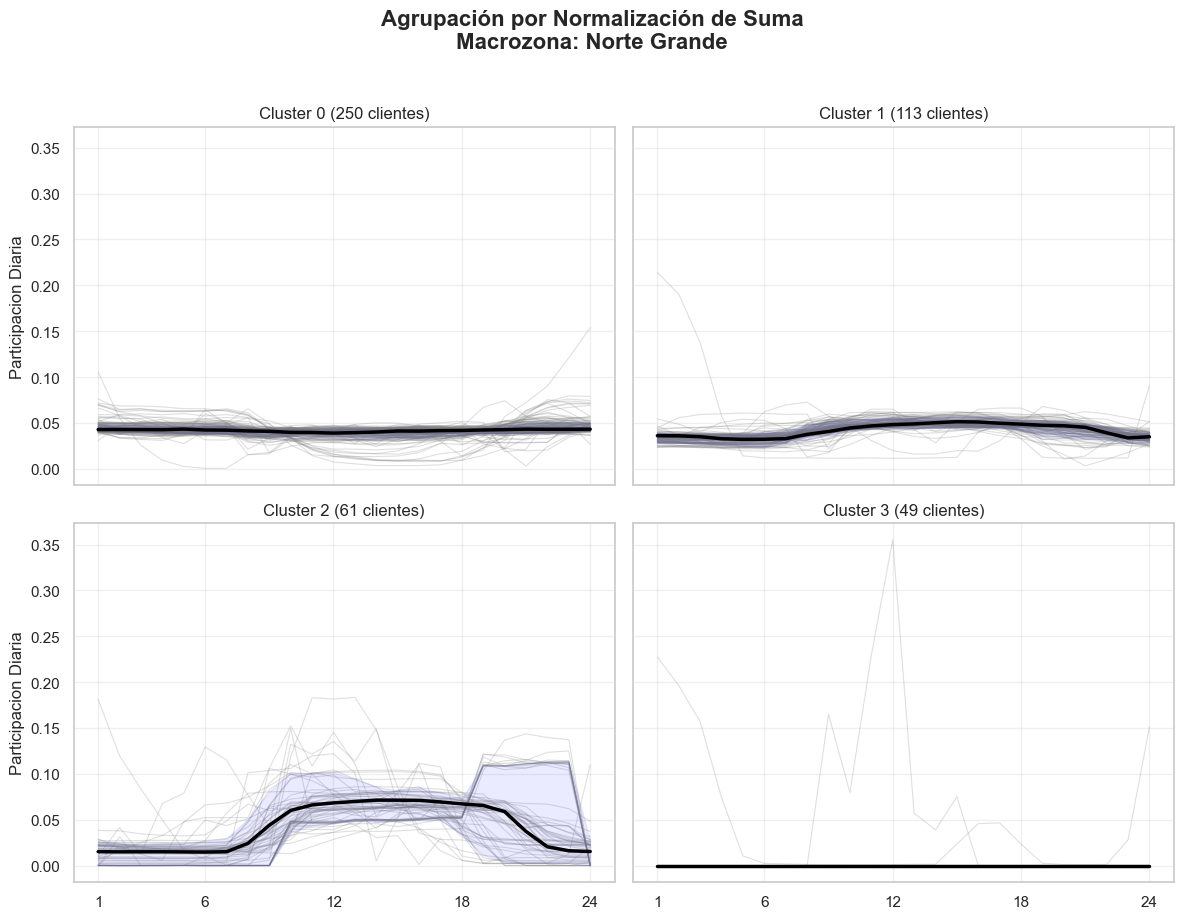

In [4]:
plot_all_clusters(
    df_data=df_clusterizado_pct, 
    df_centroids=df_centros_pct, 
    macrozona="Norte Grande", 
    col_medida="medida_porcentual", 
    titulo_principal="Agrupación por Normalización de Suma"
)

In [4]:
df_sub_centroides_pct, df_sub_clusterizado_pct = subcluster_macrozona_cluster(
    df=df_clusterizado_pct,
    macrozona_target="Norte Grande",
    cluster_target=2,
    value_col="medida_porcentual",
    k_max_global=6,  
    window=3,
    normalize=False  
)



--- SUBCLUSTERIZANDO ---
Macrozona: Norte Grande | Cluster Padre: 2
 |- Claves unicas a procesar: 61
 |- Total de registros: 1,464
Buscando codo DTW en rango 2-6...
✅ Codo DTW detectado en K=3

SUBCLUSTERIZACION COMPLETADA CON EXITO


In [8]:
df_sub_clusterizado_pct[df_sub_clusterizado_pct["id_subcluster"] == 1][["Razon_Social","medida_total"]]

,Razon_Social,medida_total
312,Pozo Almonte Solar 2 S.A.,-50178.425534
313,Pozo Almonte Solar 2 S.A.,-50178.425534
314,Pozo Almonte Solar 2 S.A.,-50178.425534
315,Pozo Almonte Solar 2 S.A.,-50178.425534
316,Pozo Almonte Solar 2 S.A.,-50178.425534
...,...,...
10771,AES Andes S.A.,-819.067566
10772,AES Andes S.A.,-819.067566
10773,AES Andes S.A.,-819.067566
10774,AES Andes S.A.,-819.067566


In [ ]:
df_sub_clusterizado_pct.


Generando visualización de los subclusters...


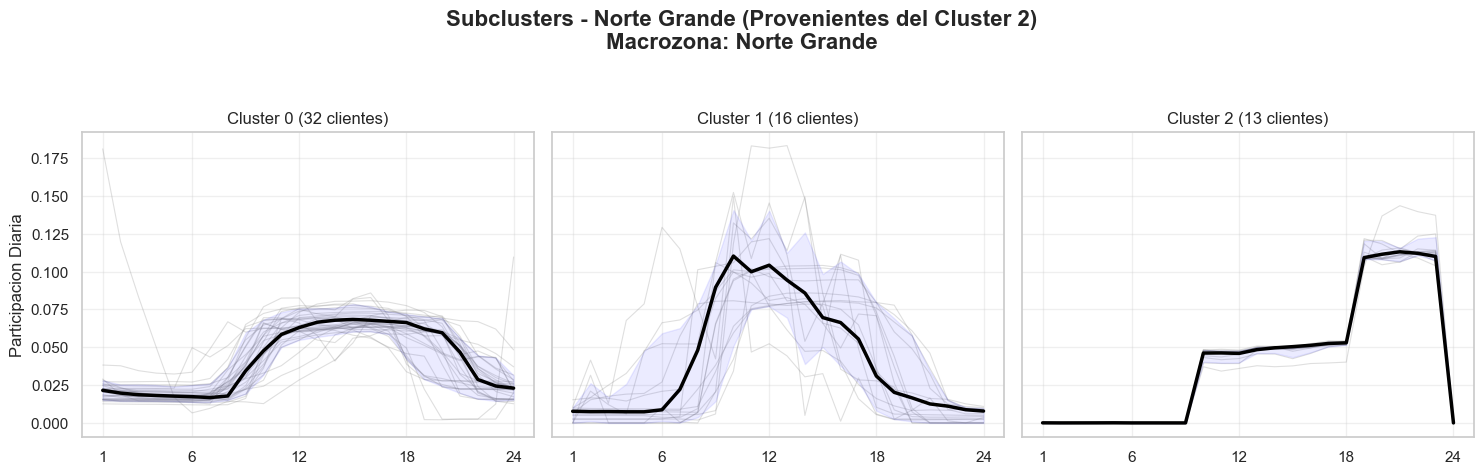

In [8]:
if df_sub_clusterizado_pct is not None:
    # Copias de seguridad
    df_plot_data = df_sub_clusterizado_pct.copy()
    df_plot_cent = df_sub_centroides_pct.copy()

    df_plot_data["id_cluster"] = df_plot_data["id_subcluster"]
    df_plot_cent["id_cluster"] = df_plot_cent["id_subcluster"]
  

    if "clave_unica" not in df_plot_data.columns:
        df_plot_data["clave_unica"] = df_plot_data["clave"].astype(str) + "_" + df_plot_data["Zona"].astype(str)
    
    print("\nGenerando visualización de los subclusters...")
    plot_all_clusters(
        df_data=df_plot_data, 
        df_centroids=df_plot_cent, 
        macrozona="Norte Grande", 
        col_medida="medida_porcentual", 
        titulo_principal="Subclusters - Norte Grande (Provenientes del Cluster 2)"
    )

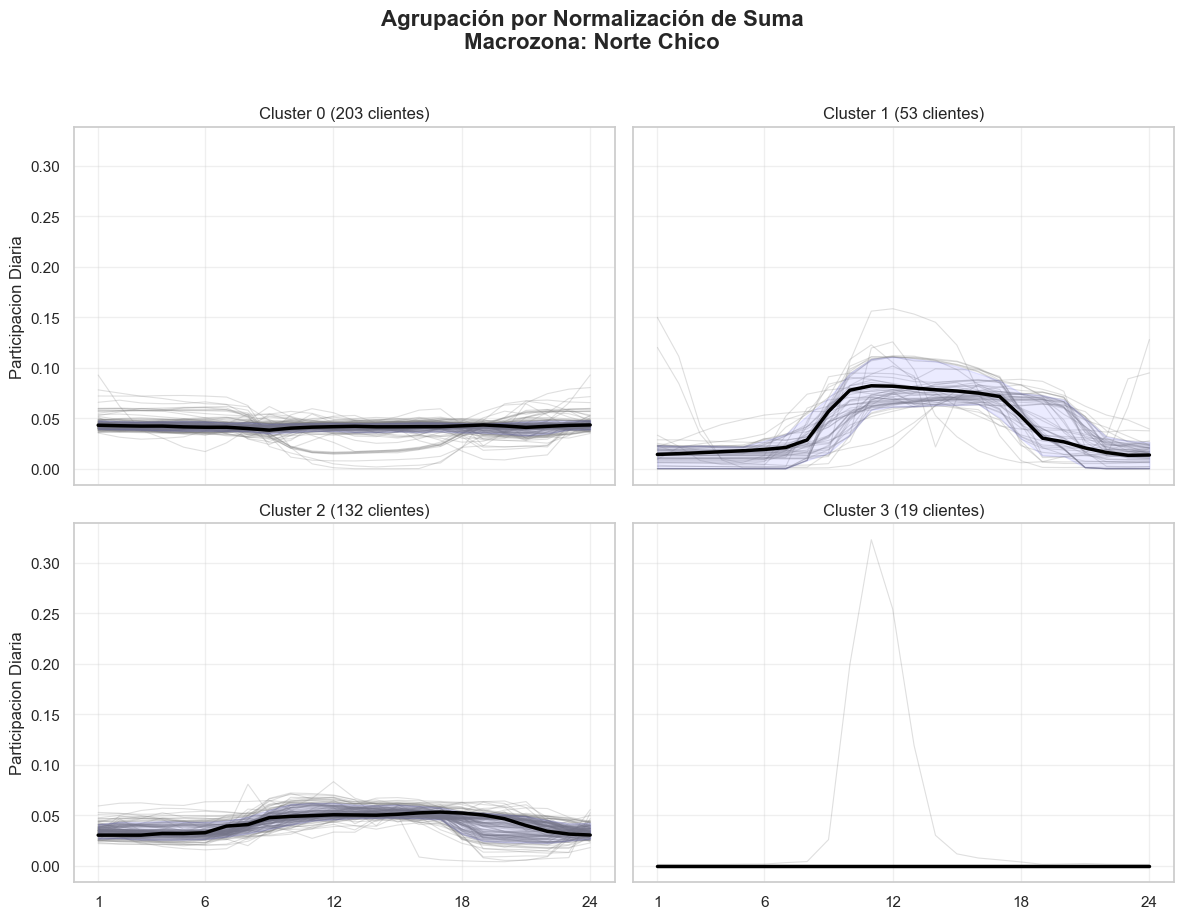

In [9]:
plot_all_clusters(
    df_data=df_clusterizado_pct, 
    df_centroids=df_centros_pct, 
    macrozona="Norte Chico", 
    col_medida="medida_porcentual", 
    titulo_principal="Agrupación por Normalización de Suma"
)

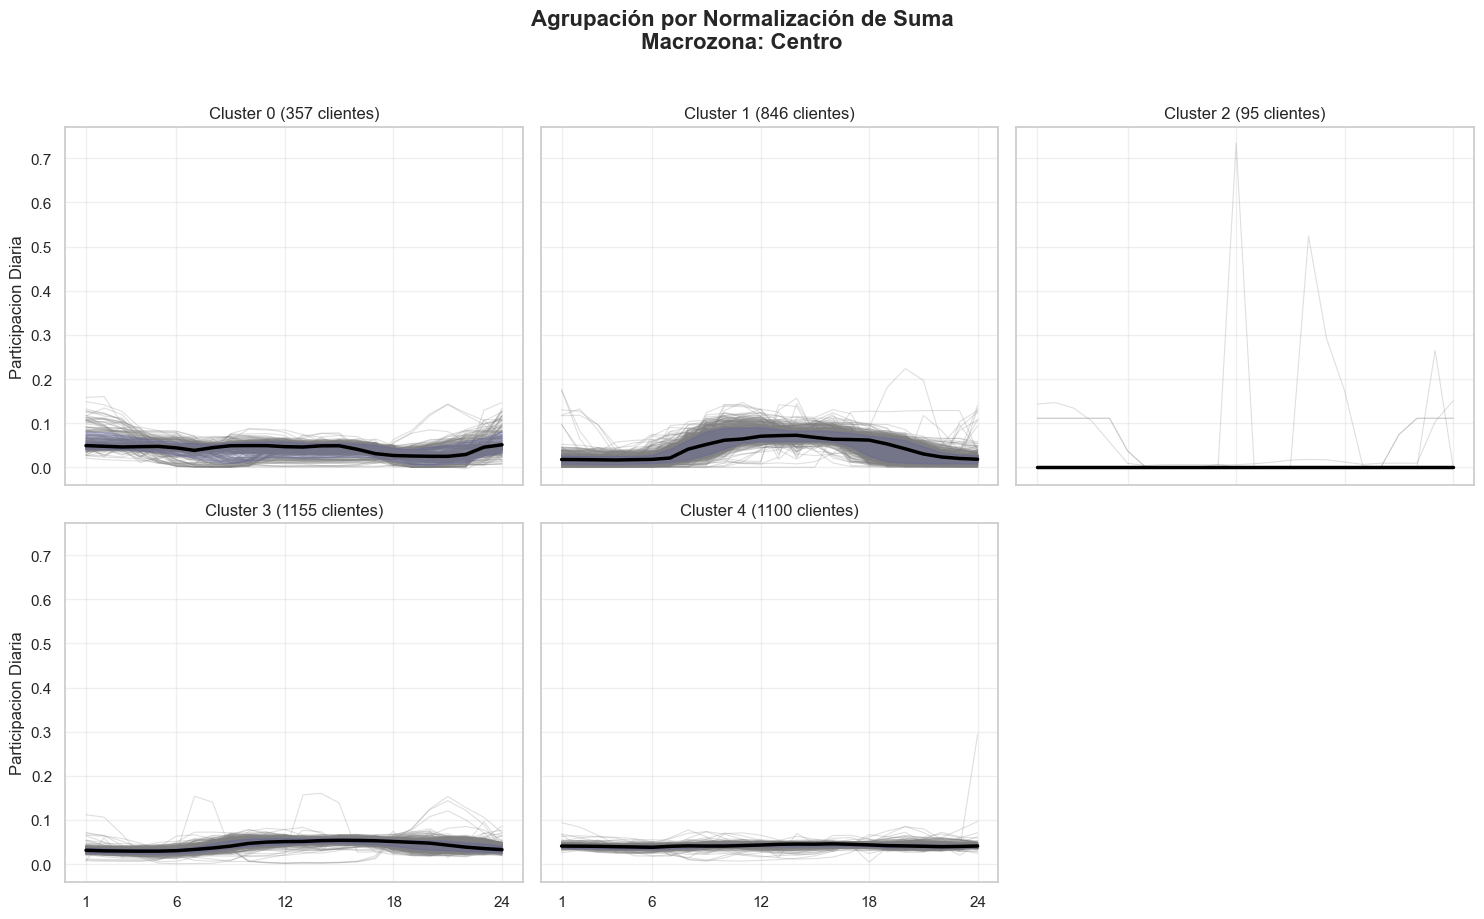

In [10]:
plot_all_clusters(
    df_data=df_clusterizado_pct, 
    df_centroids=df_centros_pct, 
    macrozona="Centro", 
    col_medida="medida_porcentual", 
    titulo_principal="Agrupación por Normalización de Suma"
)

In [22]:
df_sub_centroides_pct, df_sub_clusterizado_pct = subcluster_macrozona_cluster(
    df=df_clusterizado_pct,
    macrozona_target="Centro",
    cluster_target=2,
    value_col="medida_porcentual",
    k_max_global=6,  
    window=3,
    normalize=False  
)


--- SUBCLUSTERIZANDO ---
Macrozona: Centro | Cluster Padre: 2
 |- Claves unicas a procesar: 95
 |- Total de registros: 2,280
Buscando codo DTW en rango 2-6...
✅ Codo DTW detectado en K=4

SUBCLUSTERIZACION COMPLETADA CON EXITO



Generando visualización de los subclusters...


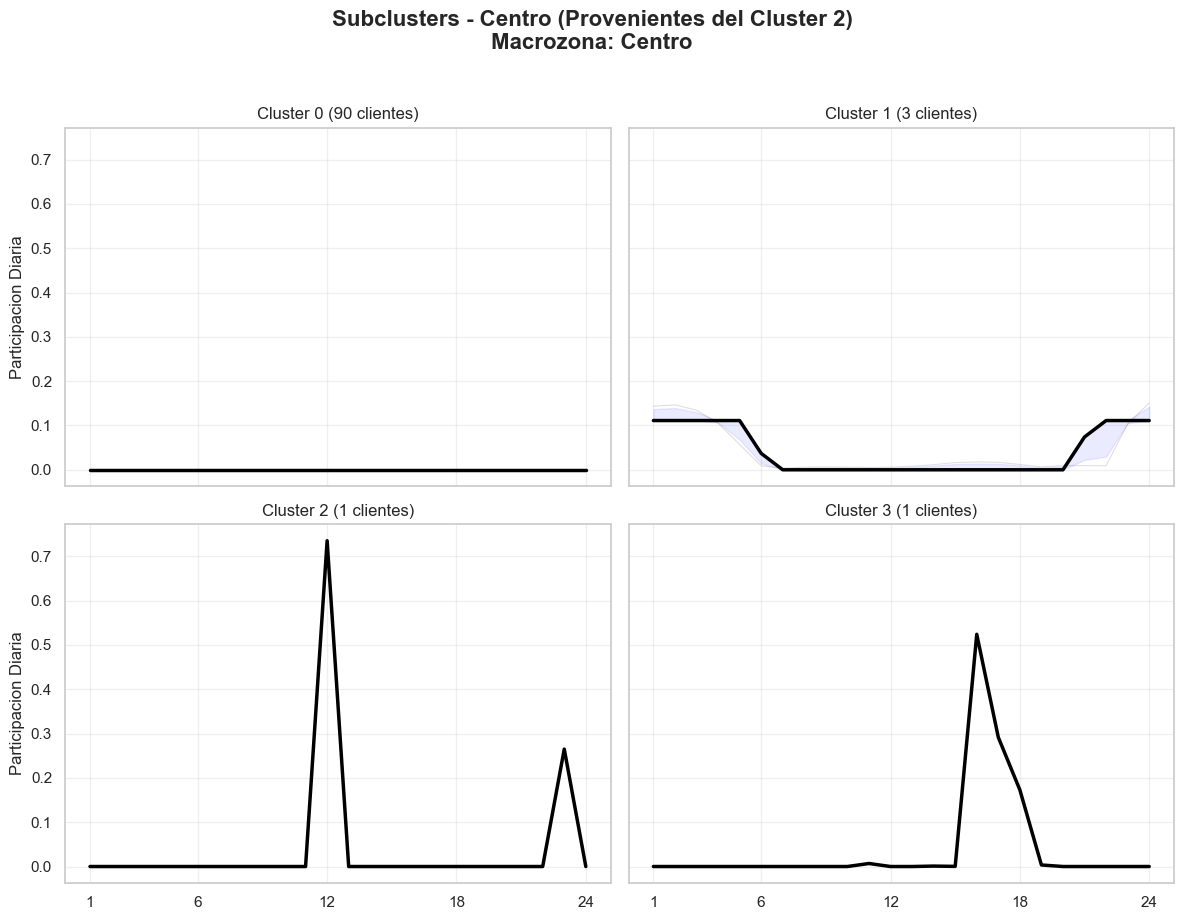

In [23]:
if df_sub_clusterizado_pct is not None:
    # Copias de seguridad
    df_plot_data = df_sub_clusterizado_pct.copy()
    df_plot_cent = df_sub_centroides_pct.copy()

    df_plot_data["id_cluster"] = df_plot_data["id_subcluster"]
    df_plot_cent["id_cluster"] = df_plot_cent["id_subcluster"]
  

    if "clave_unica" not in df_plot_data.columns:
        df_plot_data["clave_unica"] = df_plot_data["clave"].astype(str) + "_" + df_plot_data["Zona"].astype(str)
    
    print("\nGenerando visualización de los subclusters...")
    plot_all_clusters(
        df_data=df_plot_data, 
        df_centroids=df_plot_cent, 
        macrozona="Centro", 
        col_medida="medida_porcentual", 
        titulo_principal="Subclusters - Centro (Provenientes del Cluster 2)"
    )

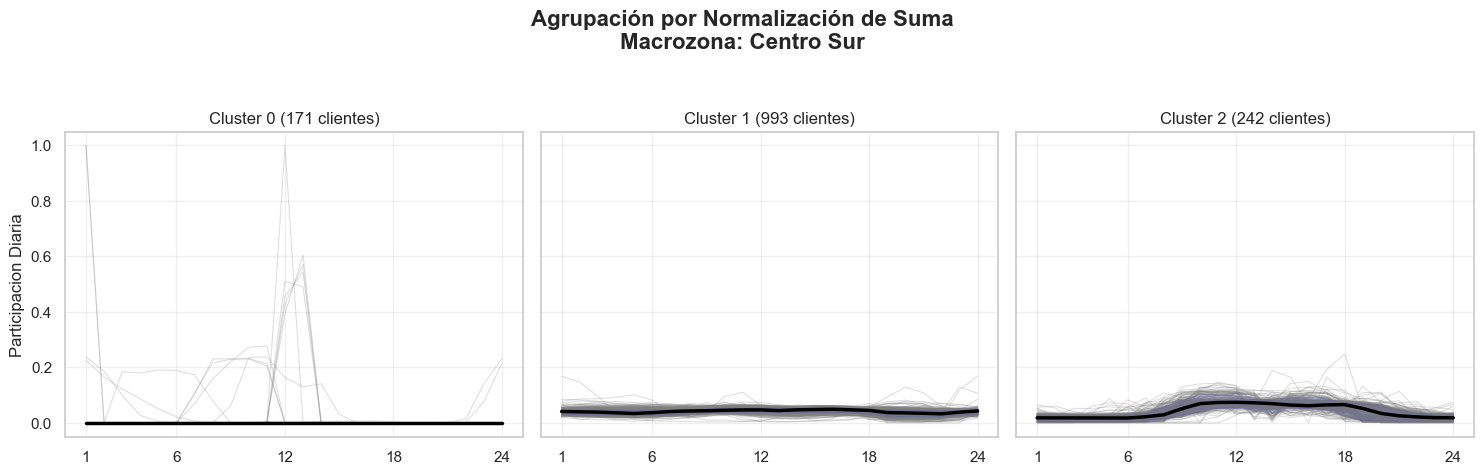

In [11]:
plot_all_clusters(
    df_data=df_clusterizado_pct, 
    df_centroids=df_centros_pct, 
    macrozona="Centro Sur", 
    col_medida="medida_porcentual", 
    titulo_principal="Agrupación por Normalización de Suma"
)

In [19]:
df_sub_centroides_pct, df_sub_clusterizado_pct = subcluster_macrozona_cluster(
    df=df_clusterizado_pct,
    macrozona_target="Centro Sur",
    cluster_target=0,
    value_col="medida_porcentual",
    k_max_global=6,  
    window=3,
    normalize=False  
)


--- SUBCLUSTERIZANDO ---
Macrozona: Centro Sur | Cluster Padre: 0
 |- Claves unicas a procesar: 171
 |- Total de registros: 4,104
Buscando codo DTW en rango 2-6...
⚠️ No se detectó un codo claro con DTW. Usando K=3 por defecto.

SUBCLUSTERIZACION COMPLETADA CON EXITO



Generando visualización de los subclusters...


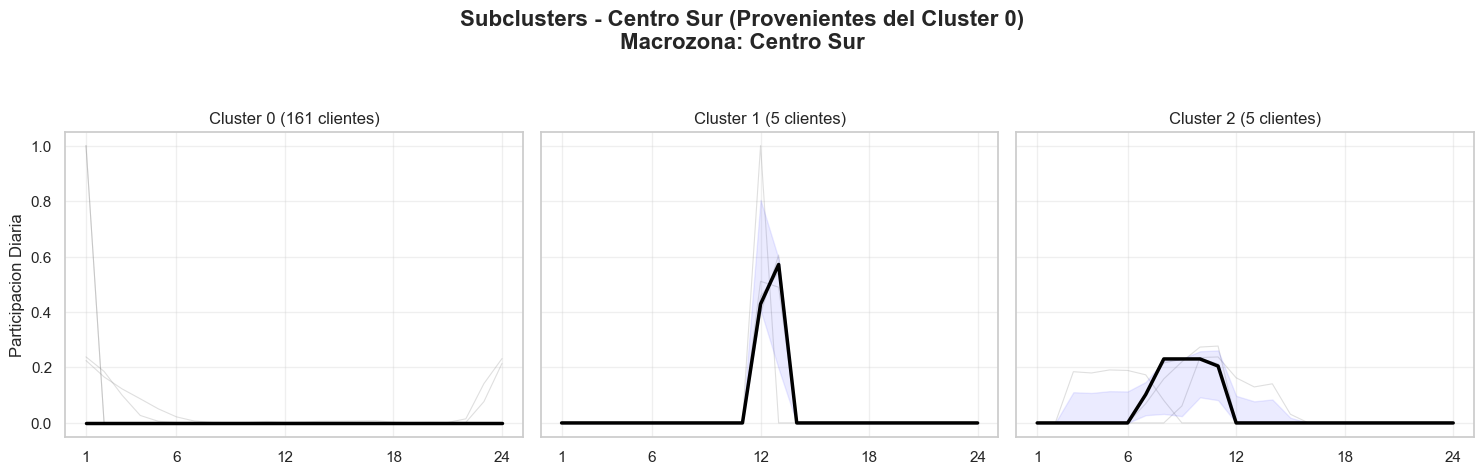

In [21]:
if df_sub_clusterizado_pct is not None:
    # Copias de seguridad
    df_plot_data = df_sub_clusterizado_pct.copy()
    df_plot_cent = df_sub_centroides_pct.copy()

    df_plot_data["id_cluster"] = df_plot_data["id_subcluster"]
    df_plot_cent["id_cluster"] = df_plot_cent["id_subcluster"]
  

    if "clave_unica" not in df_plot_data.columns:
        df_plot_data["clave_unica"] = df_plot_data["clave"].astype(str) + "_" + df_plot_data["Zona"].astype(str)
    
    print("\nGenerando visualización de los subclusters...")
    plot_all_clusters(
        df_data=df_plot_data, 
        df_centroids=df_plot_cent, 
        macrozona="Centro Sur", 
        col_medida="medida_porcentual", 
        titulo_principal="Subclusters - Centro Sur (Provenientes del Cluster 0)"
    )

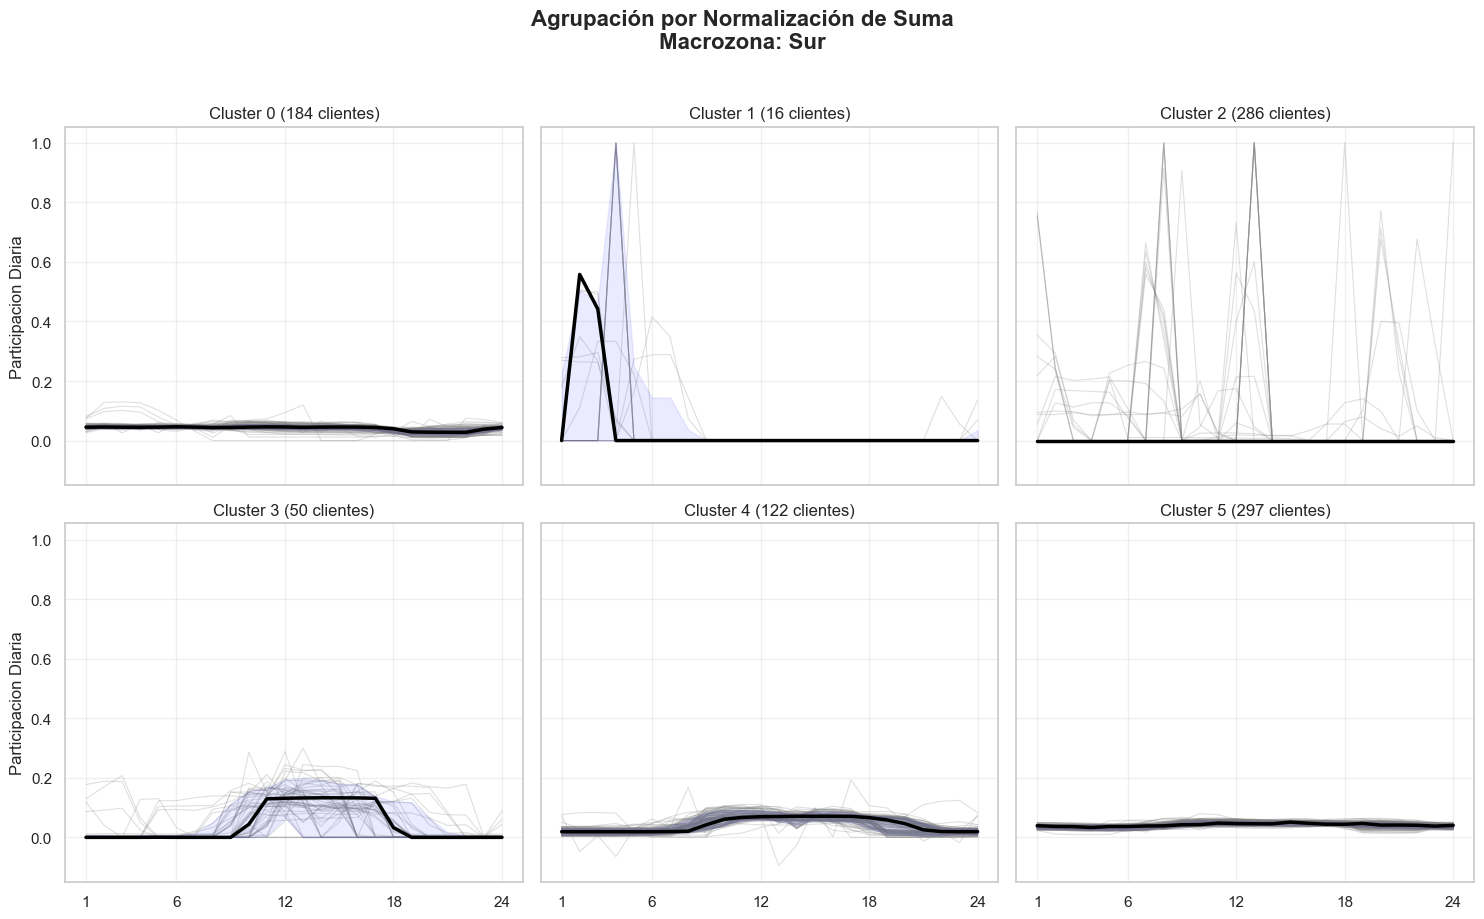

In [12]:
plot_all_clusters(
    df_data=df_clusterizado_pct, 
    df_centroids=df_centros_pct, 
    macrozona="Sur", 
    col_medida="medida_porcentual", 
    titulo_principal="Agrupación por Normalización de Suma"
)

In [15]:
df_sub_centroides_pct, df_sub_clusterizado_pct = subcluster_macrozona_cluster(
    df=df_clusterizado_pct,
    macrozona_target="Sur",
    cluster_target=2,
    value_col="medida_porcentual",
    k_max_global=8,  
    window=3,
    normalize=False  
)



--- SUBCLUSTERIZANDO ---
Macrozona: Sur | Cluster Padre: 2
 |- Claves unicas a procesar: 286
 |- Total de registros: 6,864
Buscando codo DTW en rango 2-8...
✅ Codo DTW detectado en K=6

SUBCLUSTERIZACION COMPLETADA CON EXITO



Generando visualización de los subclusters...


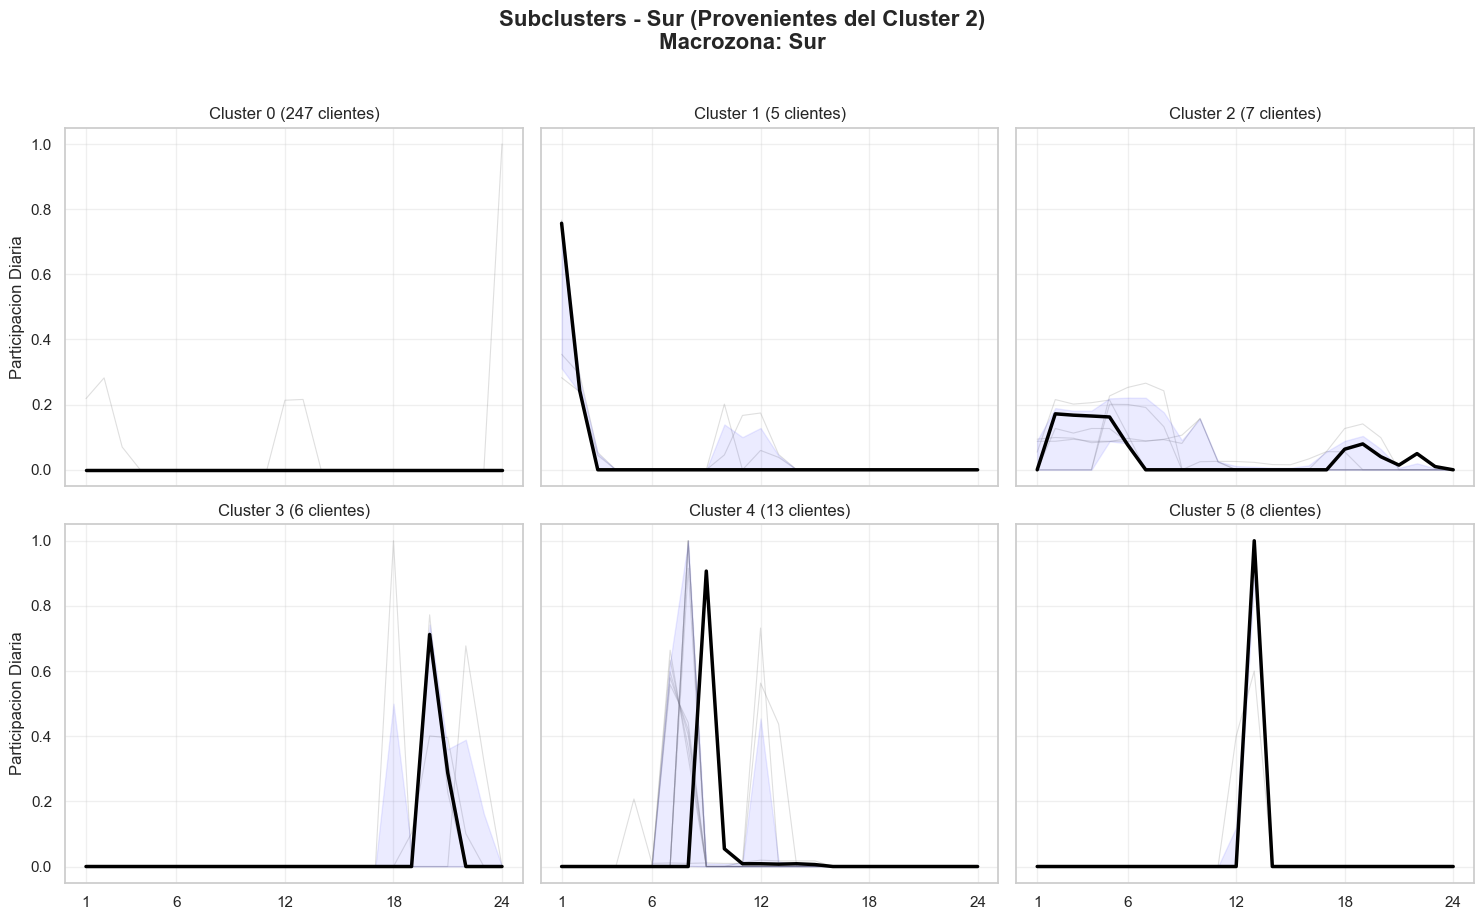

In [16]:
if df_sub_clusterizado_pct is not None:
    # Copias de seguridad
    df_plot_data = df_sub_clusterizado_pct.copy()
    df_plot_cent = df_sub_centroides_pct.copy()

    df_plot_data["id_cluster"] = df_plot_data["id_subcluster"]
    df_plot_cent["id_cluster"] = df_plot_cent["id_subcluster"]
  

    if "clave_unica" not in df_plot_data.columns:
        df_plot_data["clave_unica"] = df_plot_data["clave"].astype(str) + "_" + df_plot_data["Zona"].astype(str)
    
    print("\nGenerando visualización de los subclusters...")
    plot_all_clusters(
        df_data=df_plot_data, 
        df_centroids=df_plot_cent, 
        macrozona="Sur", 
        col_medida="medida_porcentual", 
        titulo_principal="Subclusters - Sur (Provenientes del Cluster 2)"
    )

In [17]:
df_sub_centroides_pct, df_sub_clusterizado_pct = subcluster_macrozona_cluster(
    df=df_clusterizado_pct,
    macrozona_target="Sur",
    cluster_target=3,
    value_col="medida_porcentual",
    k_max_global=8,  
    window=3,
    normalize=False  
)


--- SUBCLUSTERIZANDO ---
Macrozona: Sur | Cluster Padre: 3
 |- Claves unicas a procesar: 50
 |- Total de registros: 1,200
Buscando codo DTW en rango 2-8...
✅ Codo DTW detectado en K=6

SUBCLUSTERIZACION COMPLETADA CON EXITO



Generando visualización de los subclusters...


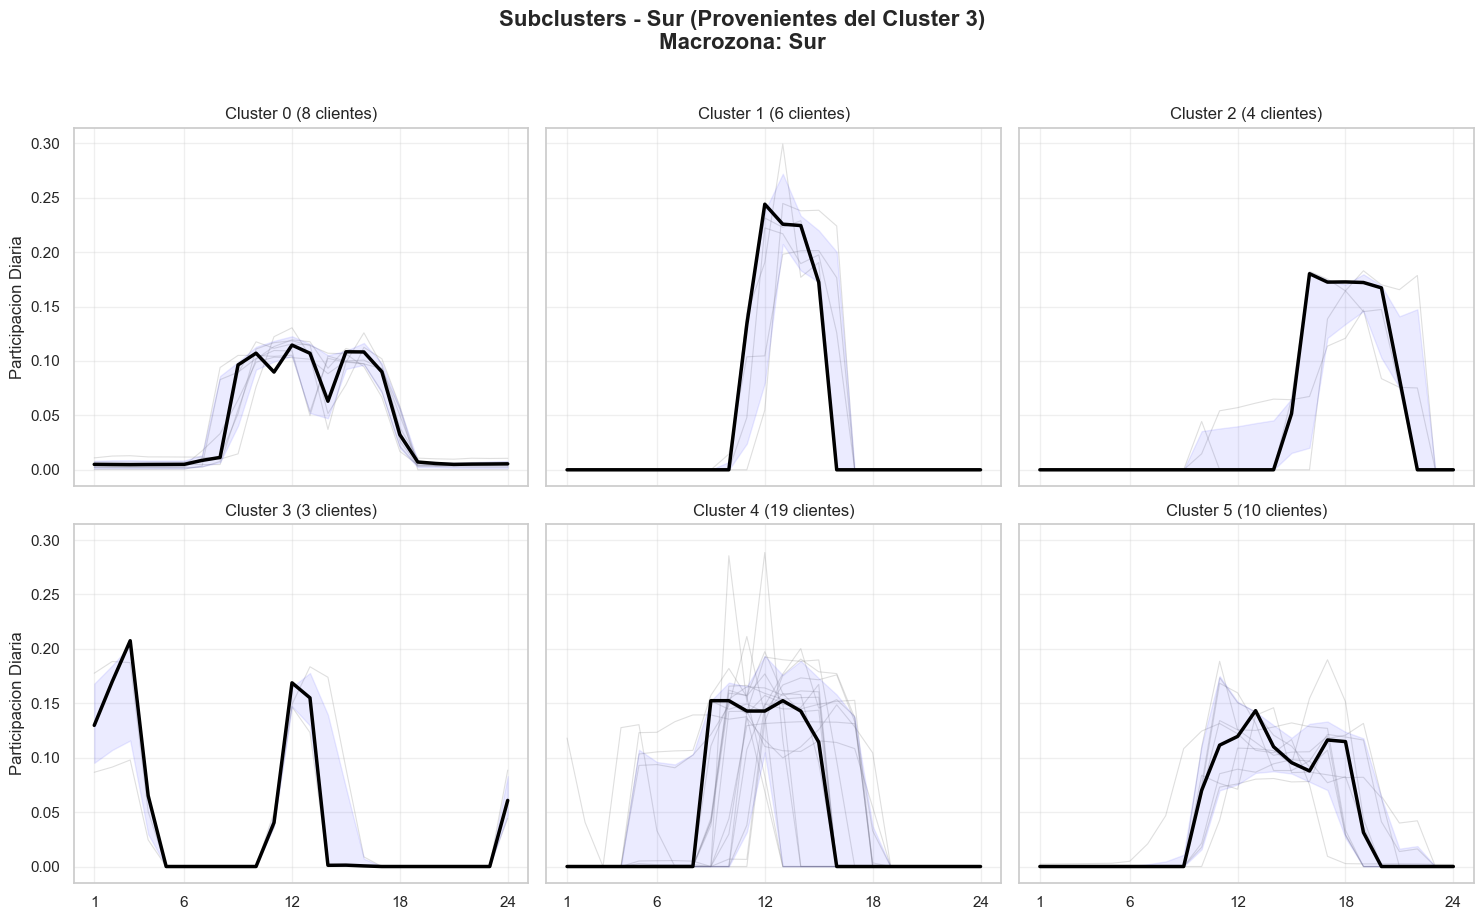

In [18]:
if df_sub_clusterizado_pct is not None:
    # Copias de seguridad
    df_plot_data = df_sub_clusterizado_pct.copy()
    df_plot_cent = df_sub_centroides_pct.copy()

    df_plot_data["id_cluster"] = df_plot_data["id_subcluster"]
    df_plot_cent["id_cluster"] = df_plot_cent["id_subcluster"]
  

    if "clave_unica" not in df_plot_data.columns:
        df_plot_data["clave_unica"] = df_plot_data["clave"].astype(str) + "_" + df_plot_data["Zona"].astype(str)
    
    print("\nGenerando visualización de los subclusters...")
    plot_all_clusters(
        df_data=df_plot_data, 
        df_centroids=df_plot_cent, 
        macrozona="Sur", 
        col_medida="medida_porcentual", 
        titulo_principal="Subclusters - Sur (Provenientes del Cluster 3)"
    )